In [ ]:
# Loan Default Prediction System

# This project predicts whether a loan applicant will be approved or rejected using classification techniques.
# It includes data preprocessing, visualization, model training, evaluation (F1 score and ROC curve), SQL integration, and prediction.

In [ ]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
sns.set_style("whitegrid")
sns.set_palette("pastel")

In [ ]:
#Loading dataset
from google.colab import files
uploaded = files.upload()

Saving processed_loan_data.csv to processed_loan_data.csv


In [ ]:
df = pd.read_csv("processed_loan_data.csv")
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,146.412162,360.0,1.0,1,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.000000,360.0,1.0,0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.000000,360.0,1.0,1,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.000000,360.0,1.0,1,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.000000,360.0,1.0,1,True,False,False,False,False,False,False,False,True


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ApplicantIncome          614 non-null    int64  
 1   CoapplicantIncome        614 non-null    float64
 2   LoanAmount               614 non-null    float64
 3   Loan_Amount_Term         614 non-null    float64
 4   Credit_History           614 non-null    float64
 5   Loan_Status              614 non-null    int64  
 6   Gender_Male              614 non-null    bool   
 7   Married_Yes              614 non-null    bool   
 8   Dependents_1             614 non-null    bool   
 9   Dependents_2             614 non-null    bool   
 10  Dependents_3+            614 non-null    bool   
 11  Education_Not Graduate   614 non-null    bool   
 12  Self_Employed_Yes        614 non-null    bool   
 13  Property_Area_Semiurban  614 non-null    bool   
 14  Property_Area_Urban      6

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,146.412162,342.000000,0.842199,0.687296
std,6109.041673,2926.248369,84.037468,64.372489,0.349681,0.463973
min,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000,0.000000
50%,3812.500000,1188.500000,129.000000,360.000000,1.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000,1.000000


/tmp/ipykernel_478/3196007662.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=df, palette="Set2")


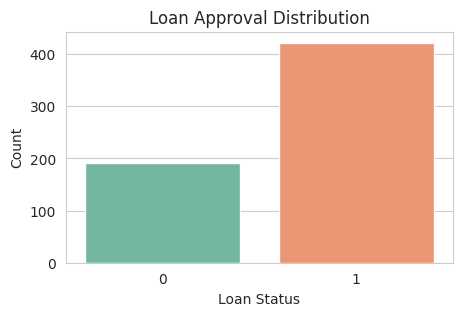

In [ ]:
plt.figure(figsize=(5,3))
sns.countplot(x='Loan_Status', data=df, palette="Set2")

plt.title("Loan Approval Distribution", fontsize=12)
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

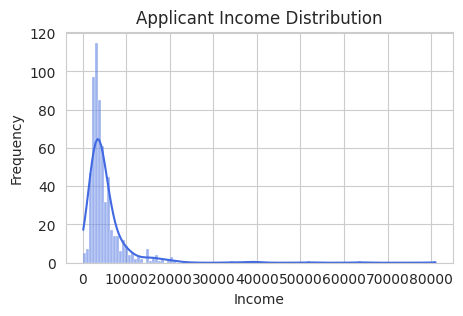

In [ ]:
plt.figure(figsize=(5,3))
sns.histplot(df['ApplicantIncome'], kde=True, color="royalblue")

plt.title("Applicant Income Distribution", fontsize=12)
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

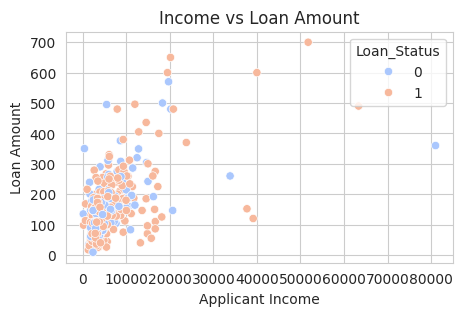

In [ ]:
plt.figure(figsize=(5,3))
sns.scatterplot(
    x='ApplicantIncome',
    y='LoanAmount',
    data=df,
    hue='Loan_Status',
    palette="coolwarm"
)

plt.title("Income vs Loan Amount", fontsize=12)
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")

plt.show()

In [ ]:
df.fillna(0, inplace=True)

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [ ]:
#Model Training
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X, y)

RandomForestClassifier(n_estimators=150, random_state=42)

In [ ]:
sample = X.iloc[0:1]
prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: [1]


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X)
print("Accuracy:", accuracy_score(y, y_pred))

Accuracy: 1.0


In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y, y_pred)
print("F1 Score:", f1)

F1 Score: 1.0


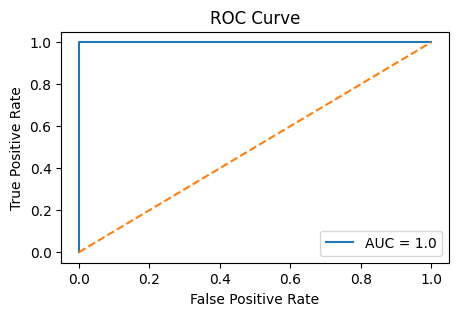

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X)[:,1]

fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,3))
plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,2)))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#SQL
import sqlite3

conn = sqlite3.connect("loan.db")

# Store data in SQL
df.to_sql("loan_data", conn, if_exists='replace', index=False)

# Query data
query = "SELECT ApplicantIncome, LoanAmount FROM loan_data LIMIT 5"
result = pd.read_sql(query, conn)

print(result)

   ApplicantIncome  LoanAmount
0             5849  146.412162
1             4583  128.000000
2             3000   66.000000
3             2583  120.000000
4             6000  141.000000


In [ ]:
#Evaluation
input_data = pd.DataFrame({
    'ApplicantIncome': [6000],
    'LoanAmount': [150],
    'Gender_Male': [1],
    'Married_Yes': [1]
})

for col in X.columns:
    if col not in input_data.columns:
        input_data[col] = 0

input_data = input_data[X.columns]

prediction = model.predict(input_data)
prob = model.predict_proba(input_data)[0][1]

print("Prediction:", prediction)
print("Approval Probability:", round(prob*100,2), "%")

Prediction: [0]
Approval Probability: 18.67 %
